In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df_aug = pd.read_csv("/Users/soroureskandari/Master Thesis /tube-bending-geometry/data/rf_augmented/geometry_augmented.csv")

In [7]:
df = df_aug.copy()

# Split
df_real = df[df["Synthetic"] == False]
df_syn = df[df["Synthetic"] == True]

In [8]:
# Numeric columns only (exclude Synthetic)
num_cols = df.select_dtypes(include="number").columns.tolist()
if "Synthetic" in num_cols:
    num_cols.remove("Synthetic")

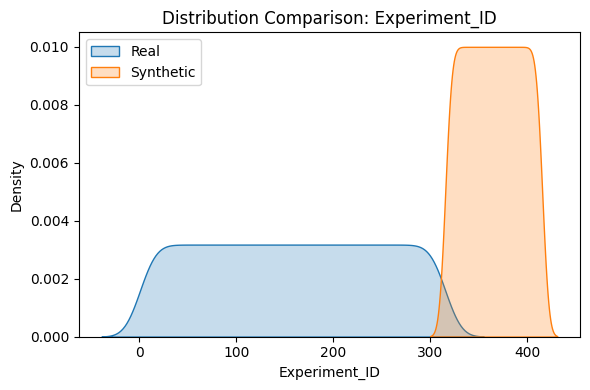

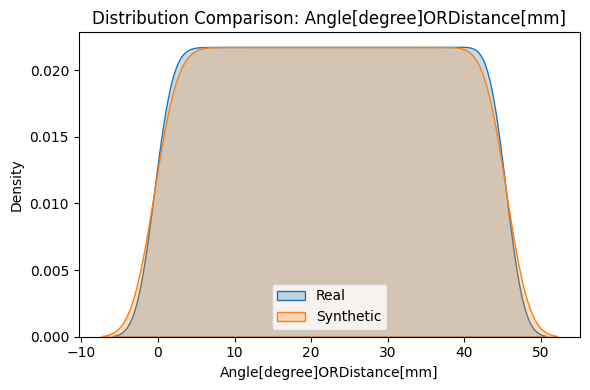

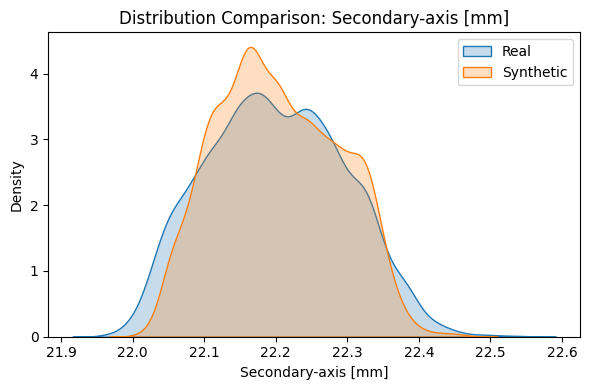

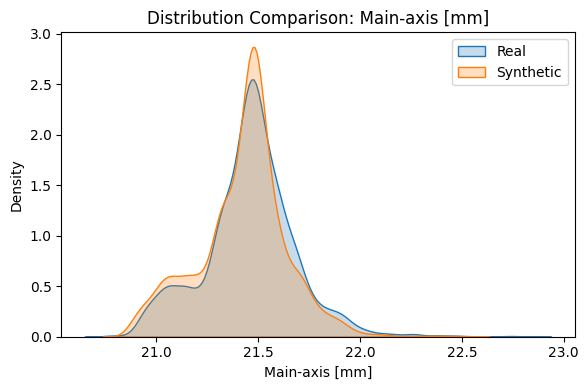

In [9]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    
    sns.kdeplot(df_real[col], label="Real", fill=True)
    sns.kdeplot(df_syn[col], label="Synthetic", fill=True)
    
    plt.title(f"Distribution Comparison: {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

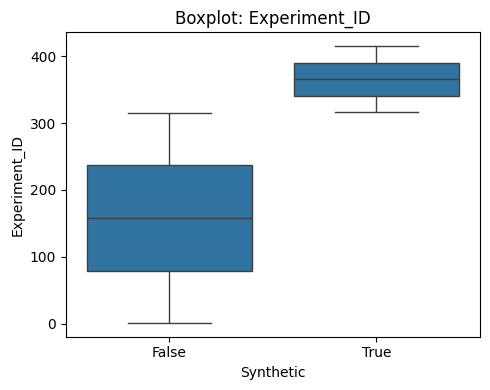

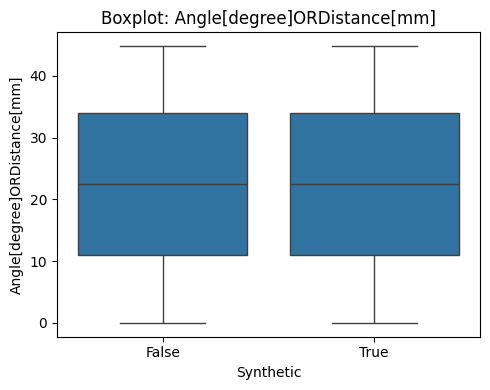

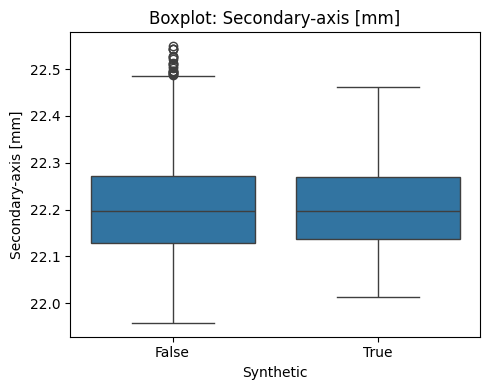

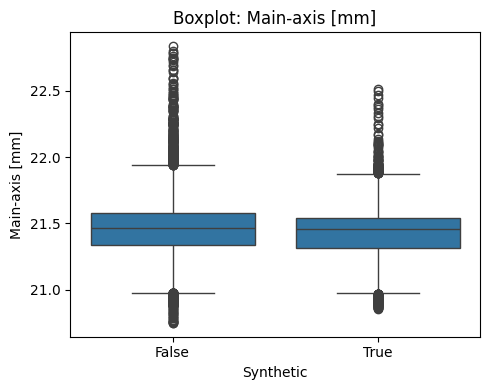

In [10]:
for col in num_cols:
    plt.figure(figsize=(5,4))
    
    sns.boxplot(data=df, x="Synthetic", y=col)
    
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

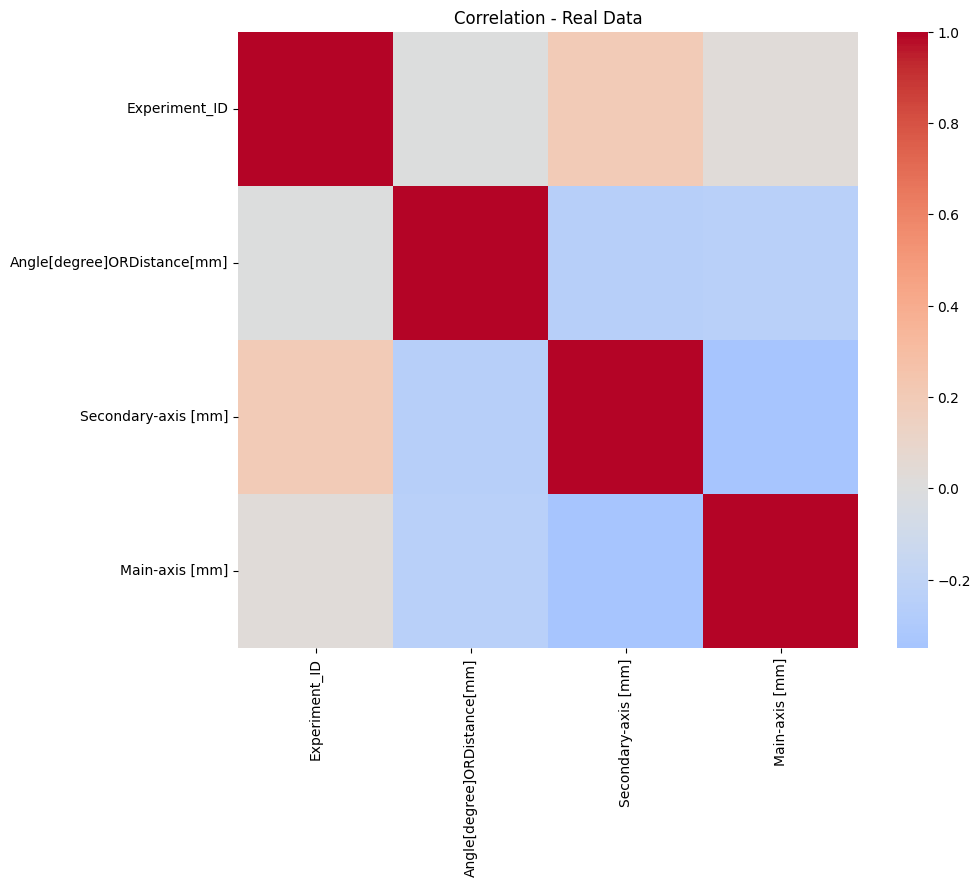

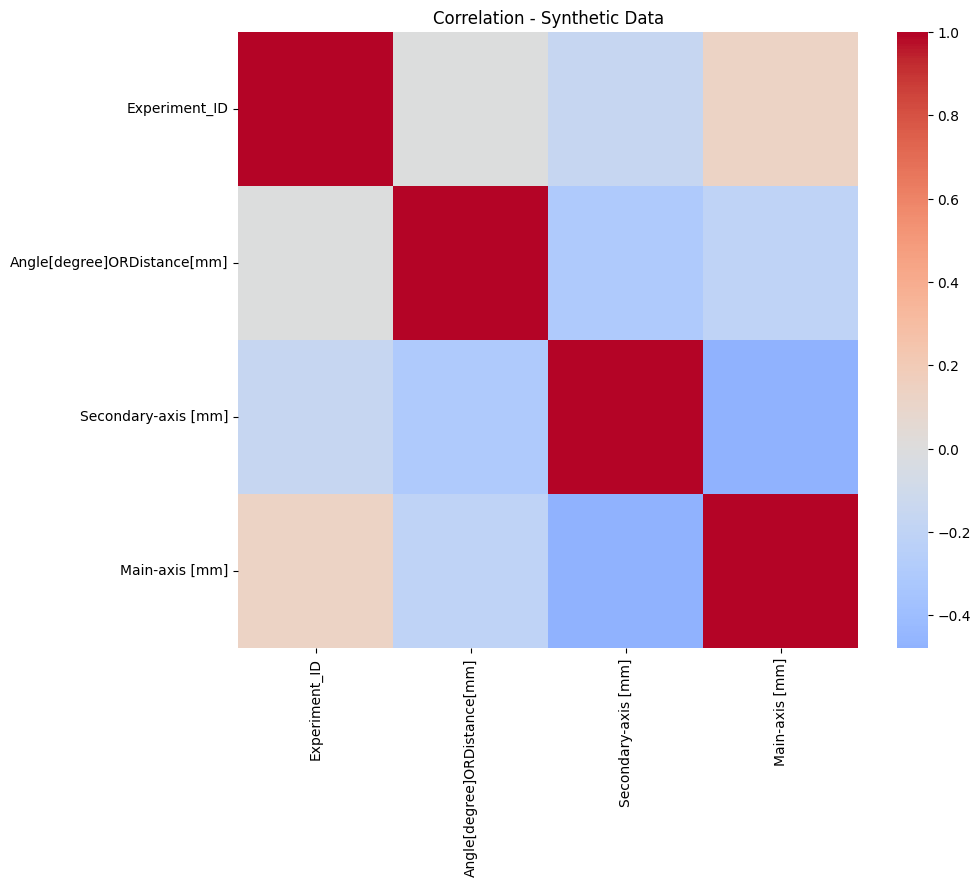

In [11]:
corr_real = df_real[num_cols].corr()
corr_syn = df_syn[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_real, cmap="coolwarm", center=0)
plt.title("Correlation - Real Data")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(corr_syn, cmap="coolwarm", center=0)
plt.title("Correlation - Synthetic Data")
plt.show()

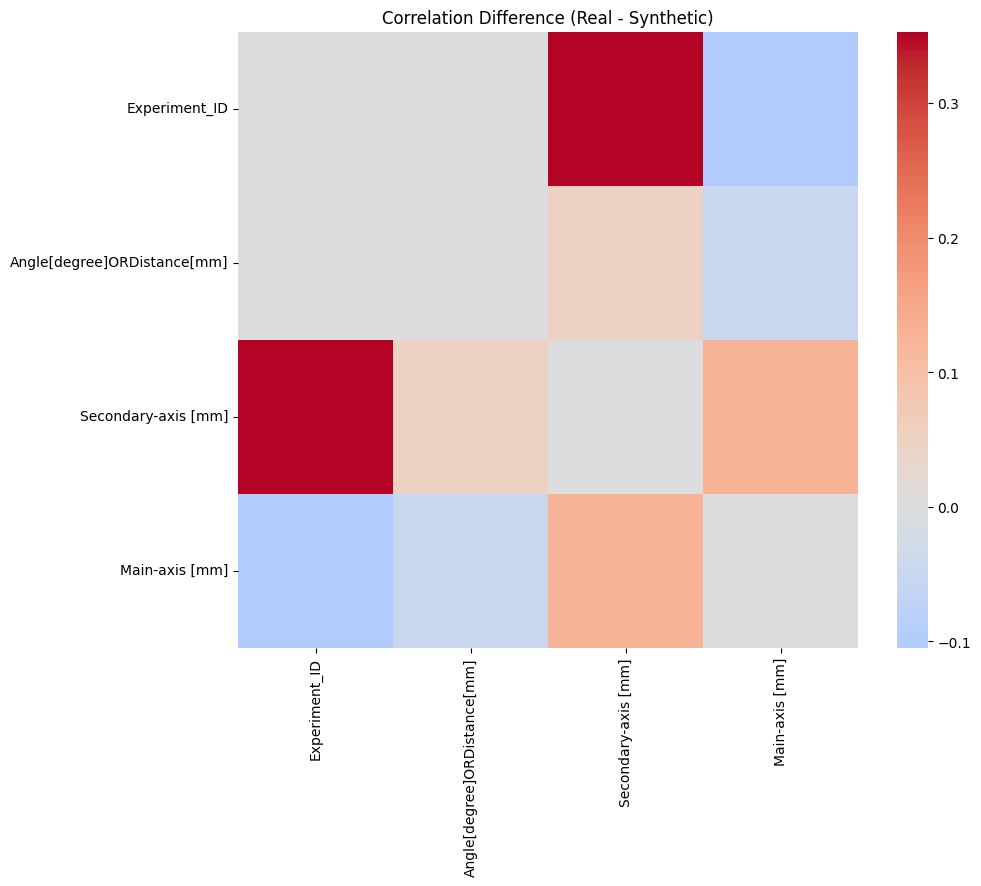

In [12]:
corr_diff = corr_real - corr_syn

plt.figure(figsize=(10,8))
sns.heatmap(corr_diff, cmap="coolwarm", center=0)
plt.title("Correlation Difference (Real - Synthetic)")
plt.show()

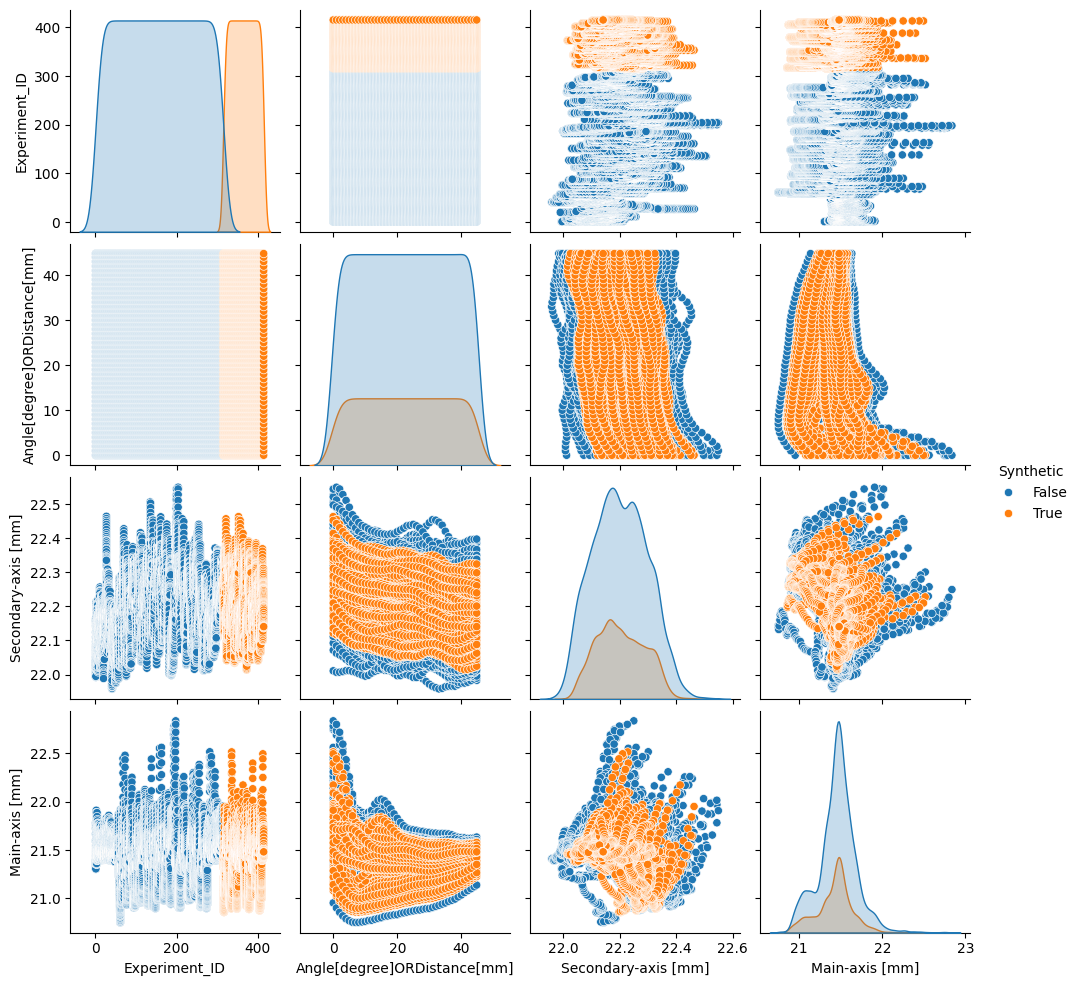

In [13]:
sample_cols = num_cols[:5]  # limit to avoid explosion
df_sample = df[sample_cols + ["Synthetic"]]

sns.pairplot(df_sample, hue="Synthetic", diag_kind="kde")
plt.show()

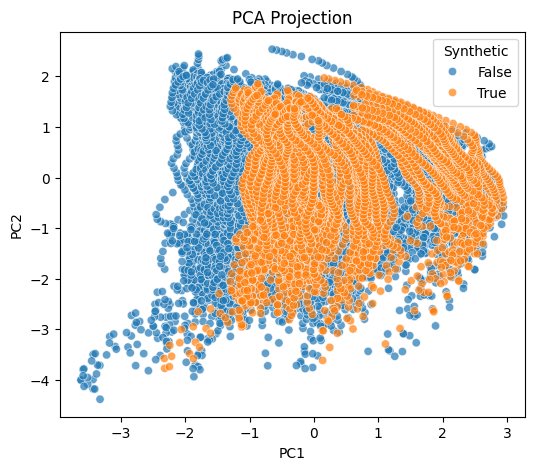

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[num_cols]

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Synthetic"] = df["Synthetic"].values

plt.figure(figsize=(6,5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Synthetic", alpha=0.7)
plt.title("PCA Projection")
plt.show()

In [17]:
from scipy.stats import ks_2samp

ks_results = {}

for col in num_cols:
    stat, pval = ks_2samp(df_real[col], df_syn[col])
    ks_results[col] = pval

ks_df = pd.DataFrame.from_dict(ks_results, orient="index", columns=["p_value"])
print(ks_df.sort_values("p_value"))

                                  p_value
Experiment_ID                0.000000e+00
Main-axis [mm]               7.322058e-20
Secondary-axis [mm]          6.620535e-11
Angle[degree]ORDistance[mm]  1.000000e+00


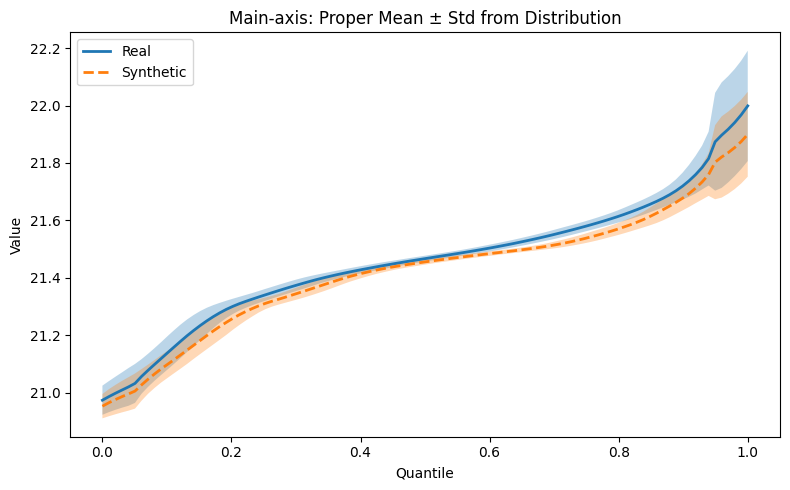

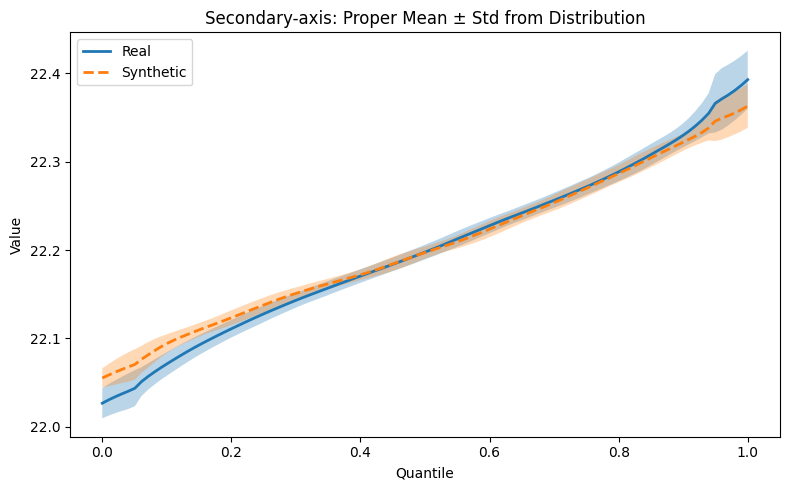

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def compute_mean_std_from_distribution(values, n_points=100, window=0.05):
    """
    Compute mean and std using local neighborhoods in quantile space
    """
    values_sorted = np.sort(values)
    n = len(values_sorted)

    x = np.linspace(0, 1, n_points)
    mean_curve = []
    std_curve = []

    for q in x:
        # Define local window in quantile space
        low_q = max(0, q - window)
        high_q = min(1, q + window)

        low_idx = int(low_q * (n - 1))
        high_idx = int(high_q * (n - 1))

        local_vals = values_sorted[low_idx:high_idx+1]

        mean_curve.append(local_vals.mean())
        std_curve.append(local_vals.std())

    return x, np.array(mean_curve), np.array(std_curve)


def plot_correct_band(real_vals, syn_vals, title):
    # Compute from FULL distributions
    x, real_mean, real_std = compute_mean_std_from_distribution(real_vals)
    _, syn_mean, syn_std   = compute_mean_std_from_distribution(syn_vals)

    plt.figure(figsize=(8,5))

    # --- REAL ---
    plt.plot(x, real_mean, label="Real", linewidth=2)
    plt.fill_between(
        x,
        real_mean - real_std,
        real_mean + real_std,
        alpha=0.3
    )

    # --- SYNTHETIC ---
    plt.plot(x, syn_mean, linestyle="--", label="Synthetic", linewidth=2)
    plt.fill_between(
        x,
        syn_mean - syn_std,
        syn_mean + syn_std,
        alpha=0.3
    )

    plt.title(title)
    plt.xlabel("Quantile")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Apply
plot_correct_band(
    df_real["Main-axis [mm]"].values,
    df_syn["Main-axis [mm]"].values,
    "Main-axis: Proper Mean ± Std from Distribution"
)

plot_correct_band(
    df_real["Secondary-axis [mm]"].values,
    df_syn["Secondary-axis [mm]"].values,
    "Secondary-axis: Proper Mean ± Std from Distribution"
)